# ***Gamma Correction*** 😘

In [78]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import Image
# https://topaz.com.mt/wp-content/uploads/2016/01/Mdina-Sunset-1.jpg
img = cv2.imread("power_input.jpg", 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # type: ignore

## Power Law (Gamma) Correction

The power law is defined by the equation:
$$ s = C · r^ɣ  $$
Where:
 - $ s $ is the output pixel value
 - $ r $ is the input pixel value (normalised between 0 and 1)
 - $ C $ is a positive scaling constant, typically set to 1 for standard use
 - $ γ $ is the exponent that controls the shape of the transformation

---

In this code example:

```img_f = img.astype(np.float64)```

First converts the image's integer values into float in order to not lose any data in the conversion.

```(img_f / 255.0)```

Normalises the image with values between 0 and 1 in order to effectively make use of the 0 to 1 range in the exponential graph.

```(img_f / 255.0) ** gamma```

The actual power distribution is applied here in order to change the color distribution accordingly.

```c * 255.0 * (img_f / 255.0) ** gamma```

Firstly the result of the above is multiplied by 255 to scale the image's rgb values back to the range 0 to 255. Then the scaling constant c is applied.

```return np.clip(s, 0, 255).astype(np.uint8)```

Here the final result is put in the clip function to ensure the numbers are within the 0 to 255 range. This is just a measure to minimise bugs potentially occurring from rounding errors. Finally, the image's values are converted back to 8-bit integer.


In [65]:
def powerLaw(img, gamma, c=1.0):
	img_f = img.astype(np.float64)
	s = c * 255.0 * (img_f / 255) ** gamma
	return np.clip(s, 0, 255).astype(np.uint8)

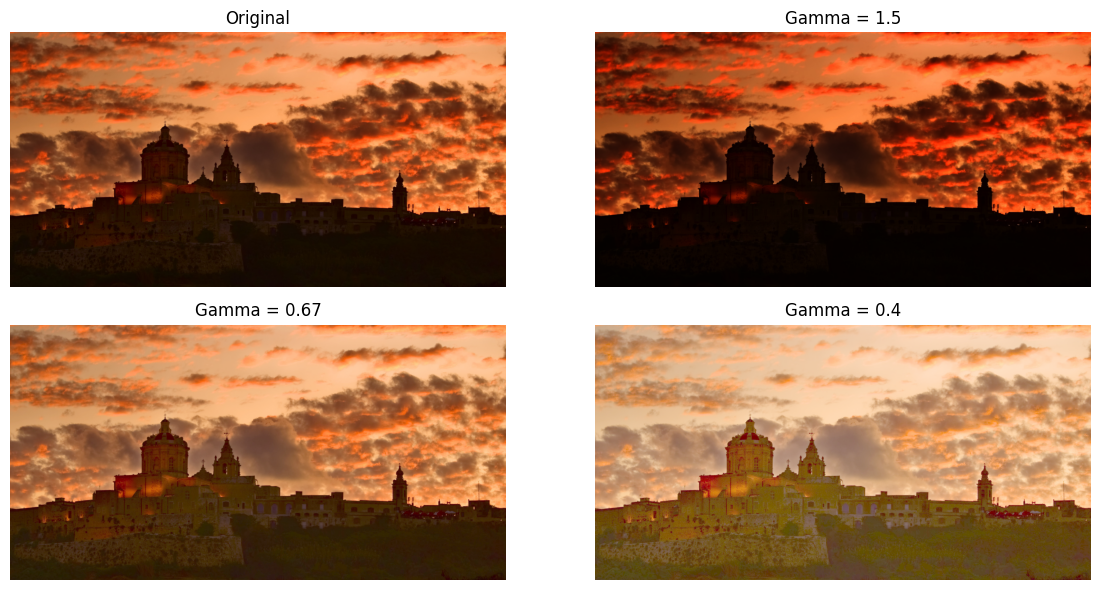

In [66]:
plot, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(powerLaw(img, gamma=1.5))
axes[0, 1].set_title('Gamma = 1.5')
axes[0, 1].axis('off')

axes[1, 0].imshow(powerLaw(img, gamma=0.67))
axes[1, 0].set_title('Gamma = 0.67')
axes[1, 0].axis('off')

axes[1, 1].imshow(powerLaw(img, gamma=0.4))
axes[1, 1].set_title('Gamma = 0.4')
axes[1, 1].axis('off')

plot.tight_layout()

## Tone Mapping Operators

bla bla bla

In [67]:
# Import HDR Image
# https://polyhaven.com/a/glasshouse_interior
hdr_img = cv2.imread('hdr_input.hdr', -1)
hdr_img = cv2.cvtColor(hdr_img, cv2.COLOR_BGR2RGB) # type: ignore

### Reinhard Operator

Reinhard tone mapping compresses HDR intensity values into a displayable range.

$$ L_d = \frac{L}{1 + L} $$

Where:

 - $ L $ = HDR luminance value
 - $ L_d $ = tone mapped output value

Visual Effect of Reinhard:
 - Preserves shadow detail
 - Compresses highlights smoothly
 - Produces natural results
 - Can appear slightly flat due to reduced contrast

---

In this code example:

```ldr_img = hdr_img / (hdr_img + 1)```
Here the image is being put in the equation 

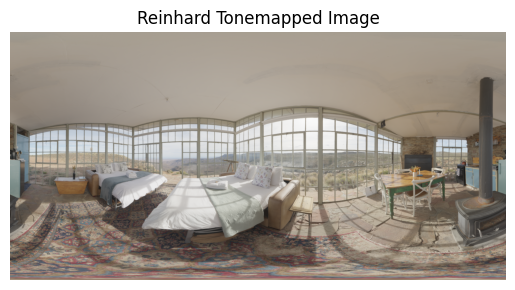

In [ ]:
ldr_img = hdr_img / (hdr_img + 1) # type: ignore

# 4. Optional: Gamma correction (Standard monitors expect 2.2)
ldr_img = np.clip(ldr_img, 0, 1)
ldr_img = np.power(ldr_img, 1.0/2.2)

# 5. Convert to 8-bit for saving/viewing
reinhard_img = (ldr_img * 255).astype(np.uint8)
plt.imshow(reinhard_img)
plt.title('Reinhard Tonemapped Image')
plt.axis('off')
plt.show()

### Hable Operator

[
f(x) = \frac{x(Ax + CB) + DE}{x(Ax + B) + DF} - \frac{E}{F}
]

Typical constants:

```python
A = 0.15
B = 0.50
C = 0.10
D = 0.20
E = 0.02
F = 0.30
```

Where:

* (x) = HDR input value
* Constants shape the filmic curve

---

## Explanation

Hable tone mapping is a filmic tone mapping operator designed to mimic the response of camera film.

The curve contains:

* A toe region for softer shadows
* A near-linear mid-tone region
* A shoulder region for smooth highlight compression

Unlike Reinhard, Hable focuses more on cinematic contrast and smoother highlight roll-off.

Bright areas compress gradually rather than clipping abruptly, helping preserve detail and producing a more visually pleasing image.

---

## Visual Effect

* Produces cinematic contrast
* Creates softer highlights
* Preserves shadow detail
* Gives a film-like appearance
* Usually looks less flat than Reinhard


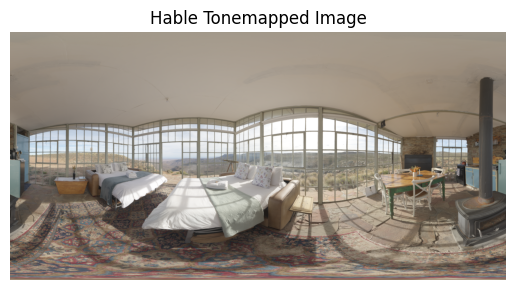

In [82]:
def hable_operator(x):
    # These constants define the shape of the filmic curve
    A = 0.15 # Shoulder Strength
    B = 0.50 # Linear Strength
    C = 0.10 # Linear Angle
    D = 0.20 # Toe Strength
    E = 0.02 # Toe Enumerator
    F = 0.30 # Toe Denominator
    # Equation: ((x*(A*x+C*B)+D*E)/(x*(A*x+B)+D*F))-E/F
    return ((x * (A * x + C * B) + D * E) / (x * (A * x + B) + D * F)) - E / F

def apply_hable(hdr_img, exposure=2.0, white_point=11.2):
    # 1. Exposure Bias (Prep the HDR data)
    x = hdr_img * exposure
    
    # 2. Apply the curve to the image
    curr = hable_operator(x)
    
    # 3. Apply the curve to the white point for normalization
    # This ensures that the brightest possible value maps to 1.0
    white_scale = 1.0 / hable_operator(white_point)
    
    # 4. Final output
    ldr = curr * white_scale
    return np.clip(ldr, 0, 1)

# Usage
ldr_result = apply_hable(hdr_img)

# Gamma correction for your monitor
ldr_corrected = np.power(ldr_result, 1.0/2.2)

hable_img = (ldr_corrected * 255).astype(np.uint8)
plt.imshow(hable_img)
plt.title('Hable Tonemapped Image')
plt.axis('off')
plt.show()

### Comparison

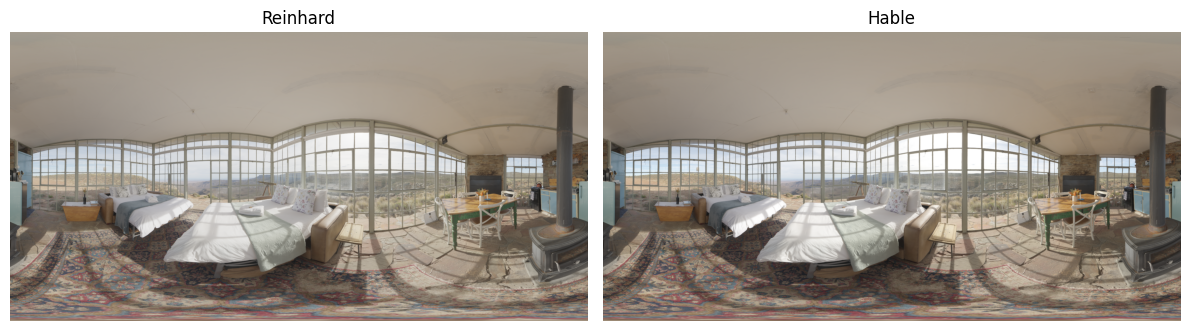

In [80]:
plot, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(reinhard_img)
axes[0].set_title('Reinhard')
axes[0].axis('off')

axes[1].imshow(hable_img)
axes[1].set_title('Hable')
axes[1].axis('off')

plot.tight_layout()

In [81]:
hdr_dr = hdr_img.max() / (hdr_img[hdr_img > 0].min())
reinhard_dr = reinhard_img.max() / (reinhard_img[reinhard_img > 0].min())
hable_dr = hable_img.max() / (hable_img[hable_img > 0].min())

print("HDR Dynamic Range:", hdr_dr)
print("Reinhard Dynamic Range:", reinhard_dr)
print("Hable Dynamic Range:", hable_dr)

HDR Dynamic Range: 13607.051
Reinhard Dynamic Range: 13.263157894736842
Hable Dynamic Range: 15.0
